In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated
from typing_extensions import TypedDict
from operator import add

class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)


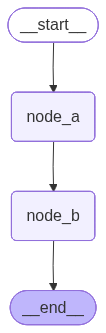

In [3]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar":[]}, config)

{'foo': 'b', 'bar': ['a', 'b']}

In [8]:
# get the latest state snapshot
config = {"configurable": {"thread_id": "1"}}
graph.get_state(config)

# # get a state snapshot for a specific checkpoint_id
# config = {"configurable": {"thread_id": "1", "checkpoint_id": "1ef663ba-28fe-6528-8002-5a559208592c"}}
# graph.get_state(config)

StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc5d0-8895-6b8a-8002-fb96e560dc35'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-28T15:21:35.386296+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc5d0-8894-662c-8001-fe11daccfe8c'}}, tasks=(), interrupts=())

In [9]:
config = {"configurable": {"thread_id": "1"}}
list(graph.get_state_history(config))

[StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc5d0-8895-6b8a-8002-fb96e560dc35'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-28T15:21:35.386296+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc5d0-8894-662c-8001-fe11daccfe8c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc5d0-8894-662c-8001-fe11daccfe8c'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-01-28T15:21:35.385752+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc5d0-8892-6c46-8000-827fb2191c16'}}, tasks=(PregelTask(id='54fb4ad8-ae8f-1ddf-b383-fc4f5cb8ac40', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts

In [11]:
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1f0fc5d0-8894-662c-8001-fe11daccfe8c"}}
graph.invoke(None, config=config)

{'foo': 'b', 'bar': ['a', 'b']}